# GraphToolbox – NetLoad Example (data1825)

This notebook adapts the standard NetLoad example to work with the  dataset.
Key differences from the original :

- **Data**:  (2018–2024, hourly, 12 French regions)
- **Targets**: , (wind), (solar)
- **Resolution**: hourly
- **Features**: temperatures in °C, nebulosity in [0, 1] from oktas, capacity-weighted weather
- **PREV columns dropped** (forecast variables excluded as inputs)

## Importing libraries

In [1]:
# General libraries
import gc
import os
import json as _json
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch_geometric.nn.conv import *
from torch_geometric.nn.models import *
from torch_geometric import seed_everything

# GraphToolbox
from graphtoolbox.data import *
from graphtoolbox.models import *
from graphtoolbox.optim import *
from graphtoolbox.training import *
from graphtoolbox.utils import *

# Autoreload
%load_ext autoreload
%autoreload 2

## Metrics

In [2]:
def _to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy().astype(float)
    return np.asarray(x, dtype=float)

def rmse_np(pred, true):
    p, t = _to_np(pred), _to_np(true)
    return float(np.sqrt(np.mean((p - t) ** 2)))

def mae_np(pred, true):
    p, t = _to_np(pred), _to_np(true)
    return float(np.mean(np.abs(p - t)))

def nrmse_np(pred, true, denom=None):
    p, t = _to_np(pred), _to_np(true)
    d = np.mean(np.abs(t)) if denom is None else float(denom)
    return 100.0 * np.sqrt(np.mean((p - t) ** 2)) / max(d, 1e-8)

def smape_np(pred, true):
    p, t = _to_np(pred), _to_np(true)
    return 100.0 * np.mean(2 * np.abs(p - t) / (np.abs(p) + np.abs(t) + 1e-8))

def mape_np(pred, true, eps=1e-6):
    p, t = _to_np(pred), _to_np(true)
    return 100.0 * np.mean(np.abs(p - t) / np.clip(np.abs(t), eps, None))

def report(name, pred, true, capacity=None):
    line = (f"{name:<28} RMSE={rmse_np(pred, true):8.0f}  "
            f"MAE={mae_np(pred, true):8.0f}  "
            f"nRMSE={nrmse_np(pred, true):6.2f}%  "
            f"sMAPE={smape_np(pred, true):6.2f}%")
    if capacity is not None:
        line += f"  nRMSE/cap={nrmse_np(pred, true, denom=capacity):6.2f}%"
    print(line)

## Feature engineering helpers

In [3]:
FRANCE_LAT_DEG = 46.6

def _day_of_year(df):
    return pd.to_datetime(df['date']).dt.dayofyear.astype(float)

def solar_declination(df):
    return 23.45 * np.sin(np.deg2rad(360.0 * (284.0 + _day_of_year(df)) / 365.0))

def day_length_hours(df, lat_deg=FRANCE_LAT_DEG):
    decl, lat = np.deg2rad(solar_declination(df)), np.deg2rad(lat_deg)
    cos_ws = np.clip(-np.tan(lat) * np.tan(decl), -1.0, 1.0)
    return (24.0 / np.pi) * np.arccos(cos_ws)

def extraterrestrial_daily(df, lat_deg=FRANCE_LAT_DEG):
    decl, lat = np.deg2rad(solar_declination(df)), np.deg2rad(lat_deg)
    ws = np.arccos(np.clip(-np.tan(lat) * np.tan(decl), -1.0, 1.0))
    dr = 1.0 + 0.033 * np.cos(np.deg2rad(360.0 * _day_of_year(df) / 365.0))
    return dr * (ws * np.sin(lat) * np.sin(decl) + np.cos(lat) * np.cos(decl) * np.sin(ws))

# Temperature in Celsius; nebulosity in [0,1]; wind in m/s
COMPUTED_FEATURES = {
    'heat_deg':     lambda df: (15.0 - df['temperature']).clip(lower=0),
    'cool_deg':     lambda df: (df['temperature'] - 15.0).clip(lower=0),
    'temp_sq':      lambda df: df['temperature'] ** 2,
    'wind_cubed':     lambda df: df['wind'].clip(lower=0) ** 3,
    'wind_cap_cubed': lambda df: df['wind_by_wind_power_weights'].clip(lower=0) ** 3,
    'clearness':    lambda df: (1.0 - df['nebulosity']).clip(lower=0, upper=1),
    'clearness_sq': lambda df: ((1.0 - df['nebulosity']).clip(lower=0, upper=1)) ** 2,
    'day_length':   lambda df: day_length_hours(df),
    'solar_pot':    lambda df: extraterrestrial_daily(df),
}
ENG_LOAD  = ['heat_deg', 'cool_deg', 'temp_sq']
ENG_WIND  = ['wind_cubed', 'wind_cap_cubed']
ENG_SOLAR = ['clearness', 'clearness_sq', 'day_length', 'solar_pot']

---
## Data preprocessing

Transform the wide  into the long per-region format expected by GraphToolbox.
Run this section once; intermediate CSVs are cached to disk.

In [10]:
TRAIN_PATH = './train_data1825.csv'
TEST_PATH  = './test_data1825.csv'

if os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH):
    print("Preprocessed CSVs already exist — skipping.  Delete them to re-run.")
else:
    print("Preprocessing data1825.csv ...")

    # 1. Load raw data
    df_raw = pd.read_csv('./data1825.csv', parse_dates=['date'])
    df_raw = df_raw.sort_values('date').reset_index(drop=True)

    # 2. Drop PREV (forecast) columns — not to be used as inputs
    drop_cols = [c for c in df_raw.columns if 'PREV' in c] + ['RealTimeLoad', 'DayValidity']
    df_raw = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns])

    # 3. Price outlier clipping (1st–99th percentile) then fill gaps
    lo, hi = df_raw['price'].quantile([0.01, 0.99])
    print(f"Price clipped to [{lo:.1f}, {hi:.1f}]")
    df_raw['price'] = df_raw['price'].clip(lower=lo, upper=hi).ffill().bfill()

    # 4. Region / city mappings
    REGION_MAP = {
        'IleDeFrance':           'Ile_de_France',
        'CentreValDeLoire':      'Centre_Val_de_Loire',
        'BourgogneFrancheComte': 'Bourgogne_Franche_Comte',
        'Normandie':             'Normandie',
        'HautsDeFrance':         'Hauts_de_France',
        'GrandEst':              'Grand Est',
        'PaysDeLaLoire':         'Pays_de_la_Loire',
        'Bretagne':              'Bretagne',
        'NouvelleAquitaine':     'Nouvelle_Aquitaine',
        'Occitanie':             'Occitanie',
        'AuvergneRhoneAlpes':    'Auvergne_Rhone_Alpes',
        'PACA':                  'Provence_Alpes_Cote_d_Azur',
    }
    REGIONS = list(REGION_MAP.keys())

    # Assign each météo city to its administrative region
    CITY_TO_REGION = {
        'ParisMontsouris':  'IleDeFrance',   'Trappes':         'IleDeFrance',
        'Bourges':          'CentreValDeLoire', 'Tours':          'CentreValDeLoire',
        'Dijon':            'BourgogneFrancheComte', 'Nevers':    'BourgogneFrancheComte',
        'Caen':             'Normandie',
        'Lille':            'HautsDeFrance',   'BoulogneSurMer': 'HautsDeFrance',
        'Abbeville':        'HautsDeFrance',
        'TroyesBarberey':   'GrandEst',        'NancyEssey':     'GrandEst',
        'Strasbourg':       'GrandEst',        'BaleMulhouse':   'GrandEst',
        'Nantes':           'PaysDeLaLoire',
        'Brest':            'Bretagne',        'Rennes':         'Bretagne',
        'Bordeaux':         'NouvelleAquitaine', 'Limoges':      'NouvelleAquitaine',
        'Nimes':            'Occitanie',       'Toulouse':       'Occitanie',
        'Montpellier':      'Occitanie',       'Tarbes':         'Occitanie',
        'Perpignan':        'Occitanie',
        'ClermontFerrand':  'AuvergneRhoneAlpes', 'LyonSatolas': 'AuvergneRhoneAlpes',
        'BourgSaintMaurice':'AuvergneRhoneAlpes',
        'SaintAuban':       'PACA',            'Nice':           'PACA',
        'Marseille':        'PACA',            'LeLuc':          'PACA',
        'Orange':           'PACA',
    }

    # Population weights for distributing national ConsolidatedLoad to regions
    POPULATION = {
        'IleDeFrance':           12395148, 'CentreValDeLoire':      2564915,
        'BourgogneFrancheComte': 2785393,  'Normandie':             3307286,
        'HautsDeFrance':         5987172,  'GrandEst':              5542094,
        'PaysDeLaLoire':         3873096,  'Bretagne':              3402932,
        'NouvelleAquitaine':     6081985,  'Occitanie':             6053548,
        'AuvergneRhoneAlpes':    8153233,  'PACA':                  5131187,
    }
    total_pop = sum(POPULATION.values())
    pop_weight = {r: p / total_pop for r, p in POPULATION.items()}

    # 5. Regional weather averages (from city T_REAL / NEB_REAL / VENT_REAL)
    def region_mean(var):
        out = {}
        for reg in REGIONS:
            cities = [c for c, r in CITY_TO_REGION.items() if r == reg]
            cols = [f'{var}.{c}' for c in cities if f'{var}.{c}' in df_raw.columns]
            out[reg] = df_raw[cols].mean(axis=1) if cols else pd.Series(np.nan, index=df_raw.index)
        return out

    t_real    = region_mean('T_REAL')    # °C
    neb_real = region_mean('NEB_REAL') # oktas [0–8] -> will be divided by 8
    vent_real = region_mean('VENT_REAL') # m/s

    for d in [t_real, neb_real, vent_real]:
        for key in d:
            d[key] = d[key].ffill().bfill()

    # 6. DST (clock-change) week flag
    # dates in data1825.csv are UTC-aware; build tz-aware reference timestamps
    _tz = df_raw['date'].dt.tz

    def dst_weeks(years):
        flags = pd.Series(0, index=df_raw.index, dtype=int)
        for yr in years:
            for month in [3, 10]:
                last_day = pd.Timestamp(yr, month, 1, tz=_tz) + pd.offsets.MonthEnd(0)
                offset = last_day.dayofweek   # 0=Mon … 6=Sun
                last_sun = last_day - pd.Timedelta(days=offset if offset != 6 else 0)
                lo_ts = last_sun - pd.Timedelta(days=3)
                hi_ts = last_sun + pd.Timedelta(days=3)
                flags[(df_raw['date'] >= lo_ts) & (df_raw['date'] <= hi_ts)] = 1
        return flags

    dst_flag = dst_weeks(range(2018, 2025))

    # 7. Build per-region long-format dataframe
    frames = []
    for i, reg in enumerate(REGIONS):
        reg_snake = REGION_MAP[reg]
        pdan = df_raw['PeriodeDansAnnee'].astype(int)
        dt_series = df_raw['date']

        df_r = pd.DataFrame({
            'date':       dt_series,
            'Region':     reg_snake,
            'RegionInt':  i,
            # Targets
            'Load':        (df_raw['ConsolidatedLoad'] * pop_weight[reg]).values,
            'Wind_power':  df_raw[f'PROD_EOL_REAL.{reg}'].clip(lower=0).values,
            'Solar_power': df_raw[f'PROD_SOL_REAL.{reg}'].clip(lower=0).values,
            # Weather  (temperature °C | nebulosity [0,1] from oktas | wind m/s)
            'temperature':  t_real[reg].values,
            'nebulosity':   (neb_real[reg] / 8.0).values,
            'wind':         vent_real[reg].values,
            # Capacity-weighted weather
            'wind_by_wind_power_weights': (
                vent_real[reg] * df_raw[f'PI_EOL.{reg}']
                / df_raw['PI_EOL.FR'].replace(0, np.nan)
            ).values,
            'nebulosity_by_solar_power_weights': (
                (neb_real[reg] / 8.0) * df_raw[f'PI_SOL.{reg}']
                / df_raw['PI_SOL.FR'].replace(0, np.nan)
            ).values,
            'price':         df_raw['price'].values,
            # Calendar
            'day_type_jf':   df_raw['JourFerie'].astype(float).values,
            'day_type_week': (df_raw['JourSemaine'].astype(int) - 1).values,  # 0=Mon…6=Sun
            'month':         dt_series.dt.month.values,
            'year':          dt_series.dt.year.values,
            'tod':           dt_series.dt.hour.values,           # 0–23 (hourly data)
            'toy':           (dt_series.dt.dayofyear / 365.0).values,
            # Holiday periods derived from PeriodeDansAnnee
            # 1=normal | 3=spring hols | 4=back-to-school | 11-15=summer | 21-23=Christmas
            'period_holiday':   (~pdan.isin([1, 4])).astype(int).values,
            'period_summer':    pdan.isin([11, 12, 13, 14, 15]).astype(int).values,
            'period_christmas': pdan.isin([21, 22, 23]).astype(int).values,
            'period_hour_changed': dst_flag.values,
            # School holiday zones — approximated (all zones share the same indicator).
            # Replace with the official MEN calendar for zone-specific accuracy.
            'period_holiday_zone_a': (~pdan.isin([1, 4])).astype(int).values,
            'period_holiday_zone_b': (~pdan.isin([1, 4])).astype(int).values,
            'period_holiday_zone_c': (~pdan.isin([1, 4])).astype(int).values,
            'periode':        df_raw['periode'].values,
        })
        df_r['NetLoad'] = df_r['Load'] - df_r['Wind_power'] - df_r['Solar_power']
        frames.append(df_r)

    df_long = pd.concat(frames, ignore_index=True)
    df_long = df_long.sort_values(['date', 'Region']).reset_index(drop=True)

    # 8. Exponential moving averages of temperature (per region)
    # _990: alpha=0.01 (slow — 990‰ retention of past)
    # _950: alpha=0.05 (faster — 950‰ retention of past)
    for alpha, col in [(0.01, 'temperature_lisse_990'), (0.05, 'temperature_lisse_950')]:
        df_long[col] = (
            df_long.groupby('Region')['temperature']
            .transform(lambda s: s.ewm(alpha=alpha, adjust=False).mean())
        )

    # 9. Split and save
    df_train_val = df_long[df_long['periode'].isin(['train', 'valid'])].drop(columns=['periode'])
    df_test      = df_long[df_long['periode'] == 'test'].drop(columns=['periode'])

    df_train_val.to_csv(TRAIN_PATH, index=False)
    df_test.to_csv(TEST_PATH, index=False)
    print(f"Saved train+val : {df_train_val.shape} -> {TRAIN_PATH}")
    print(f"Saved test : {df_test.shape} -> {TEST_PATH}")

    # sanity: sum(Load-Wind-Solar) should equal sum(NetLoad) exactly
    diff = float(np.sqrt((
        (df_long.groupby('date')['NetLoad'].sum()
         - (df_long.groupby('date')['Load'].sum()
            - df_long.groupby('date')['Wind_power'].sum()
            - df_long.groupby('date')['Solar_power'].sum())) ** 2
    ).mean()))
    print(f"NetLoad consistency RMSE: {diff:.4f} MW  (should be 0)")

Preprocessing data1825.csv ...
Price clipped to [-0.0, 518.5]
Saved  train+val : (630936, 28)  →  ./train_data1825.csv
Saved  test      : (105396, 28)  →  ./test_data1825.csv
NetLoad consistency RMSE: 0.0000 MW  (should be 0)


### Verify preprocessed data

In [11]:
df_check = pd.read_csv(TRAIN_PATH, nrows=5)
print("Columns:", df_check.columns.tolist())
print()
print(df_check[['date','Region','Load','Wind_power','Solar_power','NetLoad',
              'temperature','nebulosity','wind']].to_string(index=False))

Columns: ['date', 'Region', 'RegionInt', 'Load', 'Wind_power', 'Solar_power', 'temperature', 'nebulosity', 'wind', 'wind_by_wind_power_weights', 'nebulosity_by_solar_power_weights', 'price', 'day_type_jf', 'day_type_week', 'month', 'year', 'tod', 'toy', 'period_holiday', 'period_summer', 'period_christmas', 'period_hour_changed', 'period_holiday_zone_a', 'period_holiday_zone_b', 'period_holiday_zone_c', 'NetLoad', 'temperature_lisse_990', 'temperature_lisse_950']

                     date                  Region        Load  Wind_power  Solar_power     NetLoad  temperature  nebulosity     wind
2017-12-31 23:00:00+00:00    Auvergne_Rhone_Alpes 7460.600390       279.0          0.0 7181.600390     5.866667    0.791667 2.433333
2017-12-31 23:00:00+00:00 Bourgogne_Franche_Comte 2548.768581       510.5          0.0 2038.268581     9.150000    0.750000 3.150000
2017-12-31 23:00:00+00:00                Bretagne 3113.846471       626.5          0.0 2487.346471     8.200000    0.125000 4.150000

---
## CUDA or not CUDA?

In [12]:
print('CUDA'*(torch.cuda.is_available())+(1-torch.cuda.is_available())*'not CUDA')

not CUDA


---
# Part 1 : Direct net-load model (one GNN)

 per region.  
A single GNN forecasts net-load directly from the union of all component features.

> **Hourly data**:   (one forecast per hour of the next day).

In [38]:
data_kwargs = {
    'node_var': 'Region',
    'features_to_lag': {'NetLoad': (1, 24), 'temperature': (-23, -1)},
    'dummies': ['tod', 'day_type_week'],
    # Train: 2018–2022  |  Val: 2023  |  Test: 2024
    'day_inf_train': '2018-01-01',
    'day_sup_train': '2023-01-01',
    'day_inf_val':   '2023-01-01',
    'day_sup_val':   '2024-01-01',
    'day_inf_test':  '2024-01-01',
    'day_sup_test':  '2025-01-01',
    'computed_features': COMPUTED_FEATURES,
}

features_load  = ['temperature', 'temperature_lisse_990', 'temperature_lisse_950',
                  'wind', 'nebulosity',
                  'toy', 'year', 'month', 'day_type_jf', 'day_type_week',
                  'period_holiday', 'period_hour_changed',
                  'period_holiday_zone_a', 'period_holiday_zone_b', 'period_holiday_zone_c',
                  'period_christmas', 'period_summer']
features_wind  = ['wind', 'wind_by_wind_power_weights', 'toy', 'year', 'month']
features_solar = ['nebulosity', 'nebulosity_by_solar_power_weights', 'toy', 'year', 'month']

features = sorted(set(features_load) | set(features_wind) | set(features_solar)
                  | set(ENG_LOAD) | set(ENG_WIND) | set(ENG_SOLAR))

out_channels = 24   # hourly forecast horizon (1 day = 24 h)

dataset_kwargs = {
    'batch_size': 32,
    'adj_matrix': 'dtw',
    'features_base': features + [f'NetLoad_l{t}' for t in range(1, 24 + 1)]
                              + [f'temperature_l{t}' for t in range(-23, 0)],
    'target_base': 'NetLoad',
}

data = DataClass(path_train=TRAIN_PATH, path_test=TEST_PATH,
                 data_kwargs=data_kwargs, folder_config='.')

graph_dataset_train = GraphDataset(data=data, period='train',
                                   graph_folder='./graph_representations/netload1825',
                                   dataset_kwargs=dataset_kwargs, out_channels=out_channels)
graph_dataset_val = GraphDataset(data=data, period='val',
                                 scalers_feat=graph_dataset_train.scalers_feat,
                                 scalers_target=graph_dataset_train.scalers_target,
                                 graph_folder='./graph_representations/netload1825',
                                 dataset_kwargs=dataset_kwargs, out_channels=out_channels)
graph_dataset_test = GraphDataset(data=data, period='test',
                                  scalers_feat=graph_dataset_train.scalers_feat,
                                  scalers_target=graph_dataset_train.scalers_target,
                                  graph_folder='./graph_representations/netload1825',
                                  dataset_kwargs=dataset_kwargs, out_channels=out_channels)

In [ ]:
# # Build graph_representations using GraphBuilder
# from graphtoolbox.data import GraphBuilder

# gb = GraphBuilder(graph_dataset_train, graph_dataset_val, graph_dataset_test,
#                   model_vgae=None, load_graph=False, load_signal=False,
#                   reduce_method='svd', folder_config='../graph_representations/netload1825')
# algos = ['space', 'correlation', 'precision', 'gl3sr', 'dtw']
# for algo in algos:
#     W = gb.build_graph(algo=algo, threshold=0.1)
#     os.makedirs(f'./graph_representations/netload1825/{algo}', exist_ok=True)
#     np.savetxt(f'./graph_representations/netload1825/{algo}/W.txt', W, delimiter='')

Algorithm to build graph: space
[GraphBuilder] Warning: found 276 non-finite entries in Y, setting to 0.
Algorithm to build graph: correlation
[GraphBuilder] Warning: found 276 non-finite entries in Y, setting to 0.
Algorithm to build graph: precision
[GraphBuilder] Warning: found 276 non-finite entries in Y, setting to 0.
Algorithm to build graph: gl3sr
[GraphBuilder] Warning: found 276 non-finite entries in Y, setting to 0.
FGL-3SR start
 17.0 %Algorithm to build graph: dtw
[GraphBuilder] Warning: found 276 non-finite entries in Y, setting to 0.


100%|██████████| 12/12 [00:00<00:00, 96.04it/s]


## Training the direct model

[Trainer] Fitting top-level model (xgb) for MinT reconciliation...
[Trainer] Top-level xgb — national aggregate errors:
split          RMSE      MAPE%      nMAE%
-----------------------------------------
train       1635.46       2.73       2.63
val         2736.74       5.47       5.09
test        2924.47       5.79       5.47
Training model...


 46%|████▌     | 137/300 [02:42<03:12,  1.18s/it]

Early stopping at epoch 137


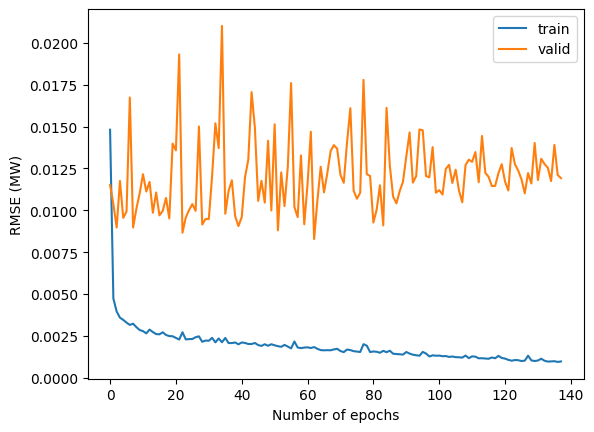

MAPE on test set: 10.6877 %
RMSE on test set: 5119.2969 MW
Direct net-load (national)   RMSE=    5119  MAE=    4155  nRMSE= 12.25%  sMAPE= 10.21%


In [39]:
gc.collect(); torch.cuda.empty_cache(); seed_everything(seed=42)

conv_class = LEConv
conv_kwargs = {}
params = {'num_layers': 2, 'hidden_channels': 256, 'lr': 1e-3,
          'batch_size': 16, 'adj_matrix': 'space', 'lam_reg': 0}

for ds in [graph_dataset_train, graph_dataset_val, graph_dataset_test]:
    ds._set_adj_matrix(adj_matrix=params['adj_matrix'])

model = myGNN(
    in_channels=graph_dataset_train.num_node_features,
    num_layers=params['num_layers'], hidden_channels=params['hidden_channels'],
    out_channels=out_channels, conv_class=conv_class, conv_kwargs=conv_kwargs,
)
trainer = Trainer(
    model=model, dataset_train=graph_dataset_train,
    dataset_val=graph_dataset_val, dataset_test=graph_dataset_test,
    batch_size=params['batch_size'],
    model_kwargs={'lr': params['lr'], 'num_epochs': 300},
    reconcile=True, top_level_model='xgb', lam_reg=0,
)
pred_model_test, target_test, edge_index, attention_weights = trainer.train(
    plot_loss=True, force_training=True, save=True, patience=75
)
trainer.evaluate()
report('Direct net-load (national)', pred_model_test.sum(0), target_test.sum(0))

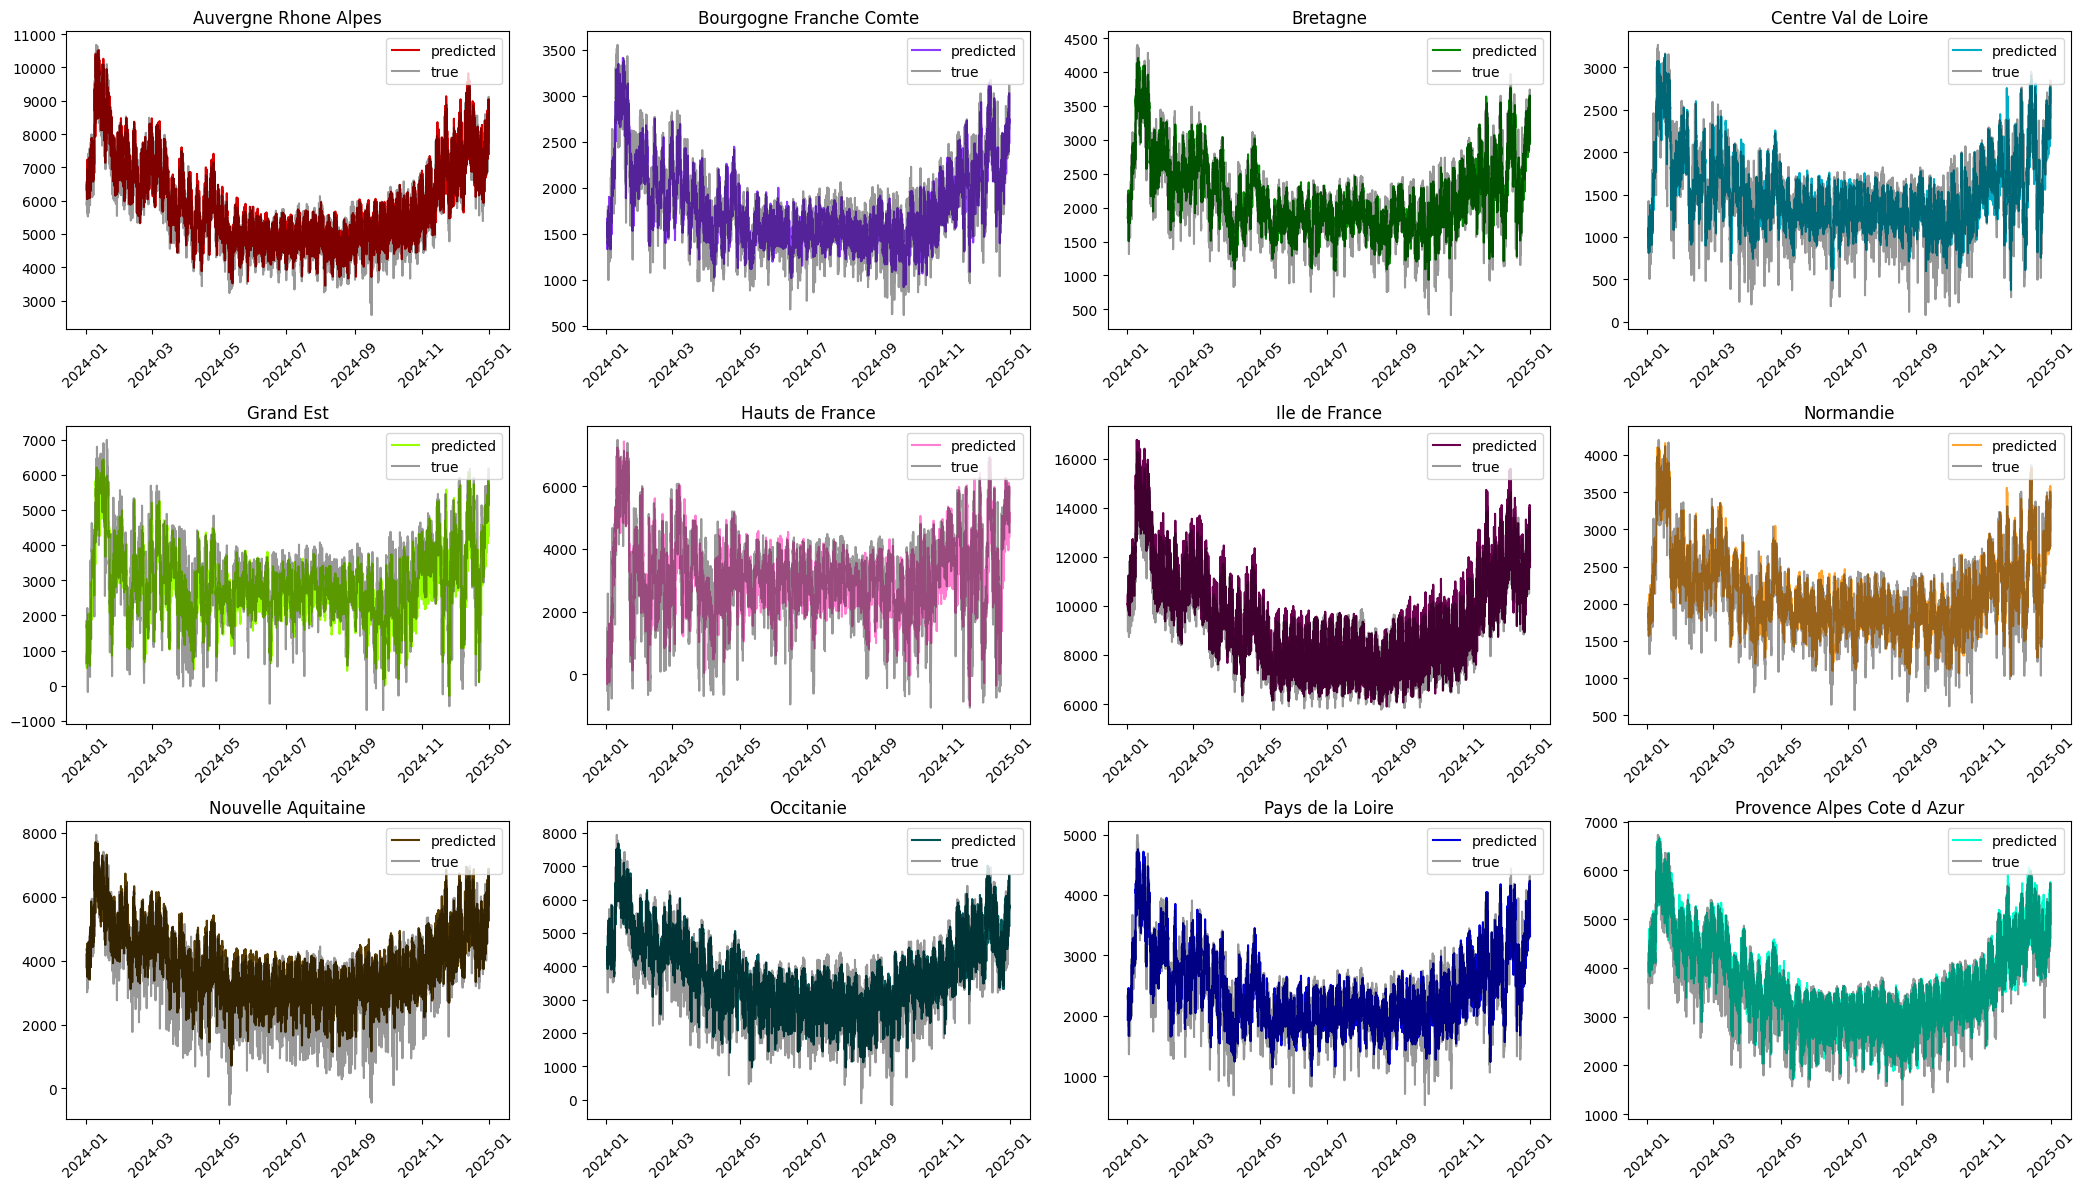

In [16]:
plot_nodes(true=target_test, pred=pred_model_test, graph_dataset=graph_dataset_test)

---
# Part 2 : Decomposition — one GNN per component (Load / Wind / Solar)

.  
Each component uses tailored features and can be tuned independently.

In [17]:
data_kwargs = {
    'node_var': 'Region',
    'features_to_lag': {
        'Load': (1, 24), 'Wind_power': (1, 24), 'Solar_power': (1, 24),
        'temperature': (-23, -1),
    },
    'dummies': ['tod', 'day_type_week'],
    'day_inf_train': '2018-01-01',
    'day_sup_train': '2023-01-01',
    'day_inf_val':   '2023-01-01',
    'day_sup_val':   '2024-01-01',
    'day_inf_test':  '2024-01-01',
    'day_sup_test':  '2025-01-01',
    'computed_features': COMPUTED_FEATURES,
}

dataset_kwargs_load = {
    'batch_size': 32, 'adj_matrix': 'dtw',
    'features_base': (features_load + ENG_LOAD
                      + [f'Load_l{t}' for t in range(1, 25)]
                      + [f'temperature_l{t}' for t in range(-23, 0)]),
    'target_base': 'Load',
}
dataset_kwargs_wind = {
    'batch_size': 32, 'adj_matrix': 'dtw',
    'features_base': (features_wind + ENG_WIND
                      + [f'Wind_power_l{t}' for t in range(1, 25)]
                      + [f'temperature_l{t}' for t in range(-23, 0)]),
    'target_base': 'Wind_power',
}
dataset_kwargs_solar = {
    'batch_size': 32, 'adj_matrix': 'dtw',
    'features_base': (features_solar + ENG_SOLAR
                      + [f'Solar_power_l{t}' for t in range(1, 25)]
                      + [f'temperature_l{t}' for t in range(-23, 0)]),
    'target_base': 'Solar_power',
}

data = DataClass(path_train=TRAIN_PATH, path_test=TEST_PATH,
                 data_kwargs=data_kwargs, folder_config='.')

def _make_datasets(dk):
    tr = GraphDataset(data=data, period='train', graph_folder='../graph_representations',
                      dataset_kwargs=dk, out_channels=out_channels)
    va = GraphDataset(data=data, period='val',   scalers_feat=tr.scalers_feat,
                      scalers_target=tr.scalers_target,
                      graph_folder='../graph_representations',
                      dataset_kwargs=dk, out_channels=out_channels)
    te = GraphDataset(data=data, period='test',  scalers_feat=tr.scalers_feat,
                      scalers_target=tr.scalers_target,
                      graph_folder='../graph_representations',
                      dataset_kwargs=dk, out_channels=out_channels)
    return tr, va, te

graph_dataset_train_load,  graph_dataset_val_load,  graph_dataset_test_load  = _make_datasets(dataset_kwargs_load)
graph_dataset_train_wind,  graph_dataset_val_wind,  graph_dataset_test_wind  = _make_datasets(dataset_kwargs_wind)
graph_dataset_train_solar, graph_dataset_val_solar, graph_dataset_test_solar = _make_datasets(dataset_kwargs_solar)

In [18]:
params_load  = {'num_layers': 2, 'hidden_channels': 128, 'lr': 1e-3, 'batch_size': 32, 'adj_matrix': 'space', 'lam_reg': 0}
params_wind  = {'num_layers': 2, 'hidden_channels': 128, 'lr': 1e-3, 'batch_size': 32, 'adj_matrix': 'space', 'lam_reg': 0}
params_solar = {'num_layers': 2, 'hidden_channels': 128, 'lr': 1e-3, 'batch_size': 32, 'adj_matrix': 'space', 'lam_reg': 0}

for ds in [graph_dataset_train_load, graph_dataset_val_load, graph_dataset_test_load]:
    ds._set_adj_matrix(adj_matrix=params_load['adj_matrix'])
for ds in [graph_dataset_train_wind, graph_dataset_val_wind, graph_dataset_test_wind]:
    ds._set_adj_matrix(adj_matrix=params_wind['adj_matrix'])
for ds in [graph_dataset_train_solar, graph_dataset_val_solar, graph_dataset_test_solar]:
    ds._set_adj_matrix(adj_matrix=params_solar['adj_matrix'])

[Trainer] Fitting top-level model (xgb) for MinT reconciliation...
[Trainer] Top-level xgb — national aggregate errors:
split          RMSE      MAPE%      nMAE%
-----------------------------------------
train        964.56       1.30       1.30
val         1370.48       1.91       1.95
test        1383.64       1.88       1.91
Training model...


 28%|██▊       | 85/300 [00:41<01:46,  2.02it/s]

Early stopping at epoch 85


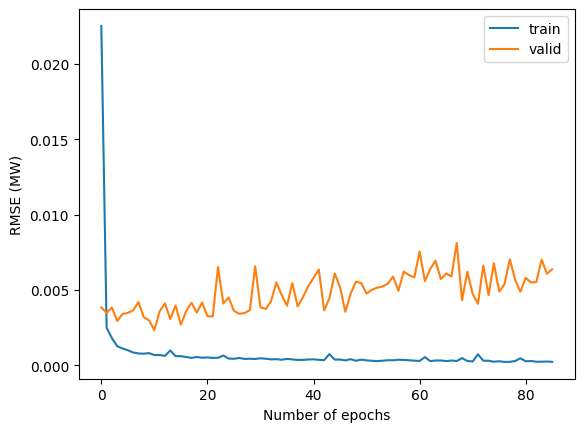

MAPE on test set: 4.8287 %
RMSE on test set: 2956.3804 MW
Load (national)              RMSE=    2956  MAE=    2269  nRMSE=  5.92%  sMAPE=  4.73%


In [20]:
### LOAD
seed_everything(seed=42); gc.collect()
model_load = myGNN(
    in_channels=graph_dataset_train_load.num_node_features,
    num_layers=params_load['num_layers'], hidden_channels=params_load['hidden_channels'],
    out_channels=out_channels, conv_class=LEConv, conv_kwargs={},
)
trainer_load = Trainer(
    model=model_load, dataset_train=graph_dataset_train_load,
    dataset_val=graph_dataset_val_load, dataset_test=graph_dataset_test_load,
    batch_size=params_load['batch_size'], return_attention=False,
    reconcile=True, top_level_model='xgb',
    model_kwargs={'lr': params_load['lr'], 'num_epochs': 300}, lam_reg=0,
)
pred_model_test_load, target_test_load, _, _ = trainer_load.train(
    plot_loss=True, force_training=True, save=True, patience=75)
trainer_load.evaluate()
report('Load (national)', pred_model_test_load.sum(0), target_test_load.sum(0))

[Trainer] Fitting top-level model (xgb) for MinT reconciliation...
[Trainer] Top-level xgb — national aggregate errors:
split          RMSE      MAPE%      nMAE%
-----------------------------------------
train       1175.31      34.19      21.40
val         1773.94      35.50      22.96
test        1853.27      43.01      25.74
Training model...


 38%|███▊      | 113/300 [00:55<01:32,  2.03it/s]

Early stopping at epoch 113


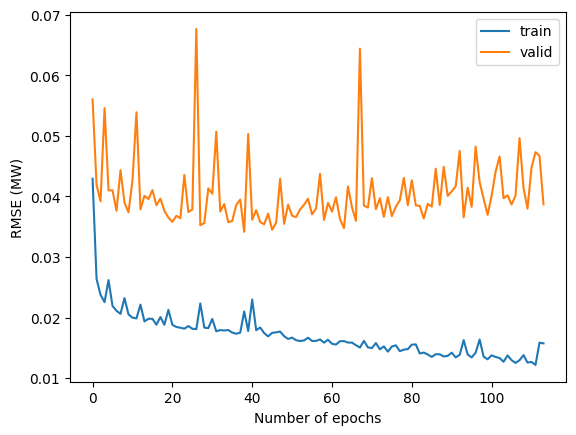

Wind (national)              RMSE=    2375  MAE=    1802  nRMSE= 44.58%  sMAPE= 41.87%


In [24]:
### WIND (near-zero often; use RMSE/nRMSE, not MAPE)
seed_everything(seed=42); gc.collect()
model_wind = myGNN(
    in_channels=graph_dataset_train_wind.num_node_features,
    num_layers=params_wind['num_layers'], hidden_channels=params_wind['hidden_channels'],
    out_channels=out_channels, conv_class=LEConv, conv_kwargs={},
)
trainer_wind = Trainer(
    model=model_wind, dataset_train=graph_dataset_train_wind,
    dataset_val=graph_dataset_val_wind, dataset_test=graph_dataset_test_wind,
    batch_size=params_wind['batch_size'], return_attention=False,
    reconcile=True, top_level_model='xgb',
    model_kwargs={'lr': params_wind['lr'], 'num_epochs': 300}, lam_reg=0,
)
pred_model_test_wind, target_test_wind, _, _ = trainer_wind.train(
    plot_loss=True, force_training=True, save=True, patience=75)
report('Wind (national)', pred_model_test_wind.sum(0), target_test_wind.sum(0))

[Trainer] Fitting top-level model (xgb) for MinT reconciliation...
[Trainer] Top-level xgb — national aggregate errors:
split          RMSE      MAPE%      nMAE%
-----------------------------------------
train        196.28 10821217600.00       6.62
val          590.49 60696691200.00      12.13
test         995.95 74777811200.00      18.14
Training model...


 39%|███▉      | 118/300 [00:57<01:28,  2.06it/s]

Early stopping at epoch 118


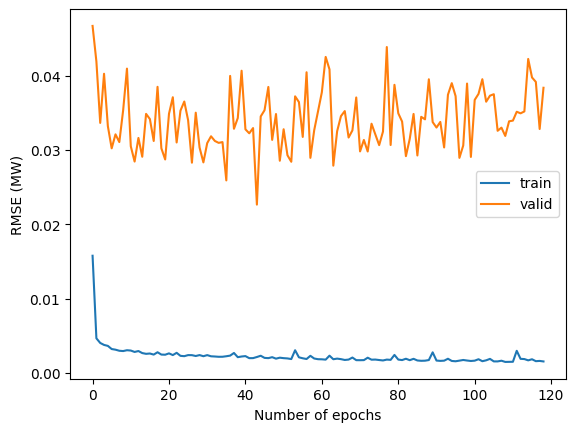

Solar (national)             RMSE=    1619  MAE=     956  nRMSE= 57.99%  sMAPE=118.73%


In [23]:
### SOLAR (zero every night; MAPE undefined — use RMSE/nRMSE only)
seed_everything(seed=42); gc.collect()
model_solar = myGNN(
    in_channels=graph_dataset_train_solar.num_node_features,
    num_layers=params_solar['num_layers'], hidden_channels=params_solar['hidden_channels'],
    out_channels=out_channels, conv_class=LEConv, conv_kwargs={},
)
trainer_solar = Trainer(
    model=model_solar, dataset_train=graph_dataset_train_solar,
    dataset_val=graph_dataset_val_solar, dataset_test=graph_dataset_test_solar,
    batch_size=params_solar['batch_size'], return_attention=False,
    reconcile=True, top_level_model='xgb',
    model_kwargs={'lr': params_solar['lr'], 'num_epochs': 300}, lam_reg=0,
)
pred_model_test_solar, target_test_solar, _, _ = trainer_solar.train(
    plot_loss=True, force_training=True, save=True, patience=75)
report('Solar (national)', pred_model_test_solar.sum(0), target_test_solar.sum(0))

## Combine components into net-load

In [25]:
pred_model_test_all = pred_model_test_load - pred_model_test_wind - pred_model_test_solar
target_test_all     = target_test_load - target_test_wind - target_test_solar

if 'target_test' in dir():
    gap = rmse_np(target_test_all.sum(0), target_test.sum(0))
    print(f"[check] decomposed truth vs direct NetLoad truth: RMSE = {gap:.1f} MW")

[check] decomposed truth vs direct NetLoad truth: RMSE = 0.0 MW


## Direct vs decomposed comparison

In [27]:
y_net = target_test_all.sum(0)
print("National net-load:")
report('  Direct (1 GNN)',                   pred_model_test.sum(0),     y_net)
report('  Decomposed (load - wind - solar)', pred_model_test_all.sum(0), y_net)

nodes = graph_dataset_test_load.nodes
print(f"{'Region':<24} {'Direct RMSE':>12} {'Decomp RMSE':>12}   winner")
print('-' * 66)
_wins = {'direct': 0, 'decomp': 0}
for i, r in enumerate(nodes):
    rd = rmse_np(pred_model_test[i],     target_test_all[i])
    rc = rmse_np(pred_model_test_all[i], target_test_all[i])
    win = 'direct' if rd < rc else 'decomp'
    _wins[win] += 1
    print(f"{r:<24} {rd:>12.0f} {rc:>12.0f}   {win}")
print(f"Region wins: direct: {_wins['direct']}, decomposed: {_wins['decomp']}")

National net-load:
  Direct (1 GNN)             RMSE=    5210  MAE=    4164  nRMSE= 12.46%  sMAPE= 10.21%
  Decomposed (load - wind - solar) RMSE=    3780  MAE=    3052  nRMSE=  9.04%  sMAPE=  7.60%
Region                    Direct RMSE  Decomp RMSE   winner
------------------------------------------------------------------
Auvergne_Rhone_Alpes              627          451   decomp
Bourgogne_Franche_Comte           206          193   decomp
Bretagne                          336          290   decomp
Centre_Val_de_Loire               304          266   decomp
Grand Est                         842          727   decomp
Hauts_de_France                  1123          978   decomp
Ile_de_France                    1026          649   decomp
Normandie                         296          280   decomp
Nouvelle_Aquitaine                827          550   decomp
Occitanie                         703          531   decomp
Pays_de_la_Loire                  378          328   decomp
Provence_Alpes

---
# Part 3 : Reconciling the two approaches (online MLpol)

Treat direct and decomposed as two experts for net-load; let MLpol learn a data-adaptive
time-varying combination per node, updated each daily block (24 steps for hourly data).

In [29]:
from opera import Mixture

step = out_channels   # 24 h
T = target_test_all.shape[1]

def _reconcile_node(experts_cols, y_node):
    df = pd.DataFrame(experts_cols)
    n = df.shape[1]
    pred = np.empty(T)
    with np.errstate(all='ignore'):
        pred[:step] = df.iloc[:step].values @ (np.ones(n) / n)
    mix = Mixture(y=y_node[:step], experts=df.iloc[:step], model='MLpol', loss_type='mse')
    for s in range(step, T, step):
        e = min(s + step, T)
        pred[s:e] = np.ravel(mix.predict(new_experts=df.iloc[s:e]))[:e - s]
        mix.update(new_experts=df.iloc[s:e], new_y=y_node[s:e])
    return pred, np.asarray(mix.weights)[-1]

N = target_test_all.shape[0]
recon_nodes = np.empty((N, T))
final_w = []
for i in range(N):
    cols = {'direct': _to_np(pred_model_test[i])[:T],
            'decomp': _to_np(pred_model_test_all[i])[:T]}
    recon_nodes[i], w = _reconcile_node(cols, _to_np(target_test_all[i])[:T])
    final_w.append(w)
recon_national = recon_nodes.sum(0)

y_net_np = _to_np(target_test_all.sum(0))[:T]
print("National net-load:")
report('  Direct',             _to_np(pred_model_test.sum(0))[:T],     y_net_np)
report('  Decomposed',         _to_np(pred_model_test_all.sum(0))[:T], y_net_np)
report('  Reconciled (MLpol)', recon_national,                         y_net_np)

final_w = np.array(final_w)
print("Final MLpol weight on *direct* expert, per region:")
for r, w in zip(nodes, final_w[:, 0]):
    print(f"  {r:<24} direct={w:4.2f}  decomp={1-w:4.2f}")

National net-load:
  Direct                     RMSE=    5210  MAE=    4164  nRMSE= 12.46%  sMAPE= 10.21%
  Decomposed                 RMSE=    3780  MAE=    3052  nRMSE=  9.04%  sMAPE=  7.60%
  Reconciled (MLpol)         RMSE=    3782  MAE=    3043  nRMSE=  9.05%  sMAPE=  7.57%
Final MLpol weight on *direct* expert, per region:
  Auvergne_Rhone_Alpes     direct=0.00  decomp=1.00
  Bourgogne_Franche_Comte  direct=0.23  decomp=0.77
  Bretagne                 direct=0.14  decomp=0.86
  Centre_Val_de_Loire      direct=0.24  decomp=0.76
  Grand Est                direct=0.00  decomp=1.00
  Hauts_de_France          direct=0.11  decomp=0.89
  Ile_de_France            direct=0.00  decomp=1.00
  Normandie                direct=1.00  decomp=0.00
  Nouvelle_Aquitaine       direct=0.00  decomp=1.00
  Occitanie                direct=0.00  decomp=1.00
  Pays_de_la_Loire         direct=0.11  decomp=0.89
  Provence_Alpes_Cote_d_Azur direct=0.00  decomp=1.00


---
# Parts 4–6 : Hyperparameter optimisation, convolution benchmark, Opera ensemble

These sections are identical to .  
Update the dataset references (e.g.  / ) and keep
 throughout.  Copy the relevant cells from  as needed.